In [1]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

def bimodal(S=1, mu=0, sigma=1):
    choose_left = np.random.randint(2, size=S)
    z = np.random.normal(0, sigma, S)
    means = np.where(choose_left == 1, mu - 2, mu + 2)
    return means + z

def huber(u, k=1.0):
    return np.where(np.abs(u) < k, 0.5 * np.power(u, 2), k * (np.abs(u) - 0.5 * k))

def du_huber(u, k=1.0):
    return np.where(np.abs(u) <= k, u, k * np.sign(u))


N = 64
tau_hat = np.asarray( [ ( (i-1)/N + i/N)/2 for i in range(1, N+1) ])

In [28]:
def ddtheta(Y, theta, S=1):
    g = np.zeros((len(theta),) )
    for y in Y:
        for i, tt in enumerate(theta):
            u = y - tt
            g[i] += 1/S * (-1) * (tau_hat[i] - (u < 0))
    return g

theta = np.zeros(N)

for k in tqdm(range(50_000)):
    g = ddtheta(bimodal(1), theta)
    theta = theta - (1/(k+1))**0.5 * g

100%|██████████| 50000/50000 [00:01<00:00, 26157.17it/s]


In [18]:
theta = np.zeros(N)

for k in tqdm(range(300_000)):
    lr = (1/(k+1))**0.5
    
    target_quantiles = bimodal() + np.zeros(N)
    pred_quantiles = theta
    
    u = ((target_quantiles[:, None] - pred_quantiles[None, :])).mean(0)
    
    # rho = -np.abs(tau_hat - (u < 0)) * du_huber(u)
    rho = -(tau_hat - (u < 0))
    
    theta -= lr * rho

100%|██████████| 300000/300000 [00:06<00:00, 48397.55it/s]


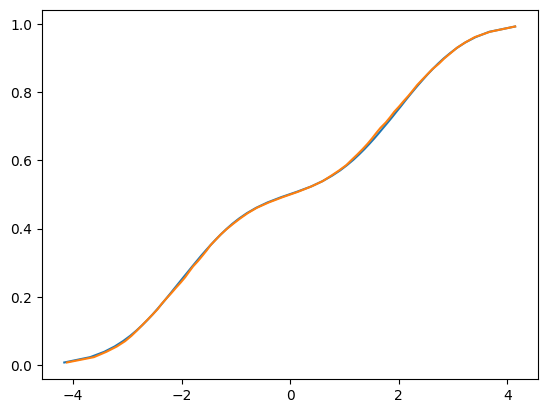

In [19]:
plt.plot(np.quantile(bimodal(300_000), tau_hat), tau_hat)
plt.plot(theta, tau_hat);

In [20]:
theta = np.zeros(N)

for k in tqdm(range(300_000)):
    lr = (1/(k+1))**0.5
    
    target_quantiles = bimodal() + np.zeros(N)
    pred_quantiles = theta
    
    u = ((target_quantiles[:, None] - pred_quantiles[None, :])).mean(0)
    
    rho = -np.abs(tau_hat - (u < 0)) * du_huber(u)
    # rho = -(tau_hat - (u < 0))
    
    theta -= lr * rho

100%|██████████| 300000/300000 [00:07<00:00, 39742.94it/s]


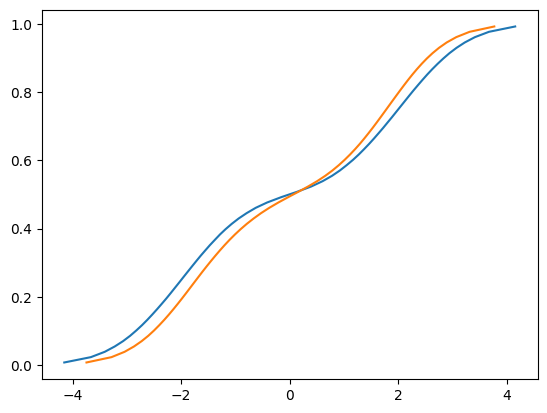

In [21]:
plt.plot(np.quantile(bimodal(300_000), tau_hat), tau_hat)
plt.plot(theta, tau_hat);